## 1. What this notebook computes

The Kohn-Sham equations of this book (its density-functional model of the field
dirac16complex in the author's primordial universe) are solved by a Rust program
of the Revision record, Revision/kohn_sham/solver, with the shooting method. This
notebook teaches that method on the simplest case of those equations and
REPRODUCES the program's results for it. It

- takes from the Revision record Revision/kohn_sham/ks-theory.json the two
  first-order equations for the two real components $a(y)$ and $b(y)$ of an
  orbital in the hidden coordinate $y$, in the free case (constant mass $M$, no
  3-space momentum, no interaction), with their boundary conditions;
- derives their exact levels: $\varepsilon = 0$ and $\pm\sqrt{M^2 + (n\pi/L)^2}$
  for the even orbitals, $\pm\sqrt{M^2 + p^2}$ with $\tan(pL) = -p/M$ for the odd
  ones;
- introduces the **Pruefer angle** $\theta = \mathrm{atan2}(b, a)$ and proves,
  with nothing more than the product rule, that its end value $\Phi$ grows with
  the energy, at the rate $d\Phi/d\varepsilon = \int r^2\,dy / r(0)^2$; so every
  level is found exactly once and carries a whole-number label;
- shoots with RK4 exactly as the Rust program does (900 steps on an interval of
  length 3) and finds every level with the program's own root finder (Newton's
  method with a bisection safety net, tolerance $10^{-13}$), re-written here line
  by line;
- reproduces all 54 levels of the record
  Revision/kohn_sham/results/spectrum/free-k0-analytic.csv (on the computer that
  made the record, in all 16 printed digits), the exact column of the record, and
  the numbers that the program's checks of this spectrum and of the zero mode
  quote;
- draws the staircase of the Pruefer angle and its slope, the winding of the
  angle along $y$, Newton against bisection, the orbitals, and the fourth-order
  convergence of the levels.

It draws 8 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 02d (Shooting two first-order equations with the Pruefer angle) is the file
`Revision/textbook/notebooks/02d_pruefer_shooting.ipynb` of the repository Dirac_claude.
It solves the simplest Kohn-Sham equations of the book, two first-order equations for the
components a and b of an orbital in the hidden coordinate (constant mass, no momentum, no
interaction), as an eigenvalue problem: it derives the exact levels, introduces the
Pruefer angle, proves with the product rule that its end value increases with the energy,
shoots with RK4 exactly as the Revision Rust solver does (900 steps on the interval of
length 3, the winding count of the angle, the Newton root finder with a bisection safety
net, tolerance 1e-13), reproduces all 54 levels of the Revision record of the free
spectrum, numeric and exact, and the numbers of the solver checks of that spectrum and of
the zero mode, and measures the fourth-order convergence of the levels. It needs a
computer with Windows 11, macOS or Linux, an internet connection for the installation,
the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
and nbconvert 7.16.6. The notebook itself imports numpy, sympy, mpmath and matplotlib;
the other packages run Jupyter, the program that shows and runs notebooks. It does not
need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 02d_pruefer_shooting.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 02d_pruefer_shooting.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
02d_pruefer_shooting.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/02d.captions.json`
- `Revision/textbook/figures/02d_1_pruefer_staircase.png`
- `Revision/textbook/figures/02d_2_staircase_slope.png`
- `Revision/textbook/figures/02d_3_angle_along_y.png`
- `Revision/textbook/figures/02d_4_odd_level_equation.png`
- `Revision/textbook/figures/02d_5_newton_vs_bisection.png`
- `Revision/textbook/figures/02d_6_orbitals.png`
- `Revision/textbook/figures/02d_7_level_convergence.png`
- `Revision/textbook/figures/02d_8_record_differences.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 8 figure files of notebook 02d exist
    ALL 17 CHECKS PASSED (notebook 02d)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/02d_pruefer_shooting.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 02d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 02d (Shooting two first-order equations with the Pruefer angle) is the file
# Revision/textbook/notebooks/02d_pruefer_shooting.ipynb of the repository Dirac_claude.
# It solves the simplest Kohn-Sham equations of the book, two first-order equations for
# the components a and b of an orbital in the hidden coordinate (constant mass, no
# momentum, no interaction), as an eigenvalue problem: it derives the exact levels,
# introduces the Pruefer angle, proves with the product rule that its end value increases
# with the energy, shoots with RK4 exactly as the Revision Rust solver does (900 steps on
# the interval of length 3, the winding count of the angle, the Newton root finder with a
# bisection safety net, tolerance 1e-13), reproduces all 54 levels of the Revision record
# of the free spectrum, numeric and exact, and the numbers of the solver checks of that
# spectrum and of the zero mode, and measures the fourth-order convergence of the levels.
# It needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy,
# mpmath and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 02d_pruefer_shooting.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 02d_pruefer_shooting.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 02d_pruefer_shooting.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/02d.captions.json
# - Revision/textbook/figures/02d_1_pruefer_staircase.png
# - Revision/textbook/figures/02d_2_staircase_slope.png
# - Revision/textbook/figures/02d_3_angle_along_y.png
# - Revision/textbook/figures/02d_4_odd_level_equation.png
# - Revision/textbook/figures/02d_5_newton_vs_bisection.png
# - Revision/textbook/figures/02d_6_orbitals.png
# - Revision/textbook/figures/02d_7_level_convergence.png
# - Revision/textbook/figures/02d_8_record_differences.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 8 figure files of notebook 02d exist
#     ALL 17 CHECKS PASSED (notebook 02d)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/02d_pruefer_shooting.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "02d"  # this notebook: chapter 02, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 02d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Orbital**: a single-particle state of the Kohn-Sham model. Here it is
  described by two real functions $a(y)$ and $b(y)$, its *components*.
- **Hidden coordinate** $y$: the book's coordinate along the hidden direction
  $x_8$, $y = \ln(\sin z)/(6H)$ with $z = 6 H x_8$; $y = 0$ is the end of the
  patch $z = \pi/2$ (the *brane*), and the interval is cut off at $y = -L$ (the
  *tip*).
- **Energy level** $\varepsilon$: a value of the energy for which the equations
  have a solution with all boundary conditions; an eigenvalue. Unit: the mass
  $m$ (in units with $m = H = 1$).
- **Mass** $M$: the constant mass of the free case; here $M = m$.
- **Boundary conditions**: at the tip $b(-L) = 0$ (the *regular tip*, a choice
  of the model); at the brane $b(0) = 0$ (*even* orbitals) or $a(0) = 0$
  (*odd* orbitals), which follow from the ASSUMED mirror symmetry of the model
  (the record labels it ASSUMED).
- **Pruefer angle** $\theta(y)$: the angle of the point $(a, b)$ seen from the
  origin, $a = r \cos\theta$, $b = r \sin\theta$ with $r > 0$; we count every
  full turn, so $\theta$ can grow beyond $2\pi$ (*winding*). $r$ is the
  distance of the point from the origin, $r^2 = a^2 + b^2$.
- **atan2(b, a)**: the angle of the point $(a, b)$ between $-\pi$ and $\pi$.
- **End angle** $\Phi(\varepsilon) = \theta(0)$: the angle reached at the brane
  when we shoot with the energy $\varepsilon$.
- **Label** $l$: the whole number that names a level through its target angle,
  $\theta(0) = l\pi$ (even) or $\pi/2 + l\pi$ (odd).
- **Monotone (increasing)**: a function that grows whenever its argument grows.
- **RK4 step count** $G$: the number of RK4 steps on $-L \le y \le 0$; the step
  is $h = L/G$.
- **Trapezoid rule**: the integral over one step approximated by the step length
  times the average of the two end values.
- **Bracket**: two energies at which $\Phi$ minus the target has opposite signs;
  the level lies between them.
- **Newton's method**: replace a function by its tangent line at the current
  guess and take the zero of that line as the next guess.
- **Transcendental equation**: an equation such as $\tan(pL) = -p/M$ that has no
  solution formula and is solved numerically.

## 4. The physical and mathematical situation

**The equations.** The record gives the Kohn-Sham equation of one 2-component
block in the real form (key `blockEquation.realForm`)
$a' = M a - (\kappa k + j(\varepsilon - v)) b$,
$b' = (j(\varepsilon - v) - \kappa k) a - M b$, where the prime is $d/dy$. In the
free case with no 3-space momentum ($k = 0$), no potential ($v = 0$), constant
mass $M$ and the block type $j = +1$ they are

$$a' = M a - \varepsilon b, \qquad b' = \varepsilon a - M b, \qquad
-L \le y \le 0,$$

with $b(-L) = 0$ at the tip and $b(0) = 0$ (even) or $a(0) = 0$ (odd) at the
brane. The record's values are $M = m = 1$, $H = 1$, $L = 3$; the program also
checks $L = 2$ and $M = 2$. In this notebook we take the equations as given; the
physics chapters derive them.

**The exact levels.** Step 1: from the first equation, $b = (M a - a')/\varepsilon$
(for $\varepsilon \ne 0$). Step 2: differentiate: $b' = (M a' - a'')/\varepsilon$.
Step 3: put both into the second equation: $(M a' - a'')/\varepsilon =
\varepsilon a - M (M a - a')/\varepsilon$. Step 4: multiply by $\varepsilon$:
$M a' - a'' = \varepsilon^2 a - M^2 a + M a'$. Step 5: cancel $M a'$:

$$a'' = (M^2 - \varepsilon^2)\, a .$$

For $|\varepsilon| > M$ put $p = \sqrt{\varepsilon^2 - M^2}$; then $a'' = -p^2 a$
and $a = \cos(p y + \varphi)$ with a constant $\varphi$. The conditions on $b$
become conditions on $a$: $b = 0$ means $M a - a' = 0$.

- Even: $M a - a' = 0$ at BOTH ends. $M\cos(py + \varphi) + p \sin(py +
  \varphi) = R \cos(py + \varphi - \delta)$ with $\tan\delta = p/M$ vanishes at
  $y = 0$ and at $y = -L$ only if the two phases differ by a multiple of $\pi$:
  $pL = n\pi$. So $\varepsilon = \pm\sqrt{M^2 + (n\pi/L)^2}$, $n = 1, 2, \dots$
- Odd: $a(0) = 0$ gives $a = \sin(py)$; the tip condition $M \sin(-pL) -
  p\cos(-pL) = 0$ gives $\tan(pL) = -p/M$.
- $\varepsilon = 0$: the equations become $a' = M a$, $b' = -M b$; with
  $b(-L) = 0$ we get $b = 0$ everywhere and $a = e^{M y}$: the *zero mode*, an
  even orbital ($b(0) = 0$) with energy exactly 0.

**The Pruefer angle.** Write $a = r\cos\theta$, $b = r\sin\theta$. Then
$\theta' = (a b' - b a')/r^2$ (the derivative of the angle of a moving point).
Insert the equations: $a b' - b a' = a(\varepsilon a - M b) - b(M a -
\varepsilon b) = \varepsilon (a^2 + b^2) - 2 M a b$. Divide by $r^2 = a^2 + b^2$
and use $2ab/r^2 = 2\sin\theta\cos\theta = \sin 2\theta$:

$$\theta' = \varepsilon - M \sin 2\theta, \qquad \theta(-L) = 0 .$$

The brane conditions say $b(0) = 0$, that is $\theta(0) = l\pi$ (even), or
$a(0) = 0$, that is $\theta(0) = \pi/2 + l\pi$ (odd), for a whole number $l$.

**How fast the end angle grows.** First the distance $r$: from $r^2 = a^2 + b^2$,
$r r' = a a' + b b' = a(M a - \varepsilon b) + b(\varepsilon a - M b) =
M(a^2 - b^2)$, and $(a^2 - b^2)/r^2 = \cos^2\theta - \sin^2\theta = \cos 2\theta$,
so $r'/r = M\cos 2\theta$. Now let $u(y) = \partial\theta(y)/\partial\varepsilon$,
the change of the angle at $y$ per unit change of the energy. Differentiate
$\theta' = \varepsilon - M\sin 2\theta$ with respect to $\varepsilon$ (the order
of the two derivatives does not matter): $u' = 1 - 2M\cos(2\theta)\, u =
1 - 2 (r'/r)\, u$. Multiply by $r^2$: $r^2 u' + 2 r r' u = r^2$. By the product
rule the left side is $(r^2 u)'$. Integrate from $-L$ to $0$; at the tip
$u(-L) = 0$, because $\theta(-L) = 0$ for every energy:

$$\frac{d\Phi}{d\varepsilon} = u(0) = \frac{1}{r(0)^2}\int_{-L}^{0} r^2\,dy > 0 .$$

So $\Phi(\varepsilon)$ increases strictly, and each target $l\pi$ or
$\pi/2 + l\pi$ is reached for exactly one $\varepsilon$: every level has its own
label $l$ and none can be missed. This is how the Rust program finds and names
its levels, and the formula gives its root finder the slope it needs.

## 5. The records and the settings

The next cell reads the three Revision records this notebook uses: the theory
(the equations, the boundary conditions with their status, the exact spectra),
the solver's parameters (900 RK4 steps, root tolerance $10^{-13}$) and the
table of the free spectrum. It prints the statements it relies on.

In [2]:
import csv  # reads the table of levels (comma-separated values)
import math  # sqrt, atan2, pi for single numbers
import re  # finds numbers inside a text

import mpmath  # numbers with as many digits as we ask for
import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols

BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
GREY, BLACK = "#8a8986", "#000000"

THEORY = "Revision/kohn_sham/ks-theory.json"
PARAMETERS = "Revision/kohn_sham/results/parameters.json"
TABLE = "Revision/kohn_sham/results/spectrum/free-k0-analytic.csv"
SOLVER_REPORT = "Revision/kohn_sham/reports/ks-rust-solver.json"
theory = json.loads(repository_file(THEORY).read_text(encoding="utf-8"))
parameters = json.loads(repository_file(PARAMETERS).read_text(encoding="utf-8"))
with open(repository_file(TABLE), encoding="utf-8", newline="") as table:
    ROWS = list(csv.DictReader(table))  # one dictionary per level
say("realForm: " + theory["blockEquation"]["realForm"])
say("brane status: " + theory["boundaryConditions"]["brane"]["status"])
say("tip status: " + theory["boundaryConditions"]["tip"]["status"])
say("exact k = 0 spectra: " + theory["boundaryConditions"]["exactK0Spectra"])
G_CANONICAL = parameters["numerics"]["rk4Steps"]  # RK4 steps for L = 3
ROOT_TOLERANCE = parameters["numerics"]["rootTolerance"]
M_RECORD, L_RECORD = parameters["physics"]["m"], parameters["physics"]["L_tipCutoff"]
report("RK4 steps, root tolerance, m, L of the record",
       f"{G_CANONICAL}, {ROOT_TOLERANCE}, {M_RECORD}, {L_RECORD}")
report("levels in the table", len(ROWS))
check(theory["boundaryConditions"]["brane"]["status"] == "ASSUMED"
      and G_CANONICAL == 900 and ROOT_TOLERANCE == 1e-13 and len(ROWS) == 54,
      "records read: brane ASSUMED, 900 RK4 steps, tolerance 1e-13, 54 levels")

realForm: chi = (a, i b), a, b real: a' = M_eff a - (kappa k + j(eps - v_v)) b, b' =
    (j(eps - v_v) - kappa k) a - M_eff b
brane status: ASSUMED
tip status: chosen (regular tip)
exact k = 0 spectra: constant M > 0, v = 0, theta = 0: even: eps = 0 with chi = (e^{My},
    0), and eps = +-sqrt(M^2 + (n pi/L)^2); odd: eps = +-sqrt(M^2 + p^2) with tan(pL) =
    -p/M
RESULT RK4 steps, root tolerance, m, L of the record = 900, 1e-13, 1.0, 3.0
RESULT levels in the table = 54
PASS records read: brane ASSUMED, 900 RK4 steps, tolerance 1e-13, 54 levels


## 6. Shooting with RK4 and counting the turns of the angle

The function `shoot` follows the Rust program (file
Revision/kohn_sham/solver/src/shoot.rs) line by line: it starts at the tip
with $(a, b) = (1, 0)$, so $\theta = 0$; makes $G$ RK4 steps of the two
equations; after every step it takes the new angle `atan2(b, a)`, adds the
change of angle since the last step (brought into the range from $-\pi$ to
$\pi$, so that a full turn is never lost: one step turns the point by much less
than $\pi$) and so counts every turn. Along the way it adds up
$\int r^2\,dy$ with the trapezoid rule. It returns $\Phi = \theta(0)$, the slope
$d\Phi/d\varepsilon = \int r^2\,dy / r(0)^2$ of section 4, the largest turn of a
single step (the program refuses a shot in which one step turns by 2 or more),
and, when asked, the whole path. (The program also shrinks $(a, b)$ when they
become astronomically large, above $10^{125}$; that never happens here.)

The second function integrates the single angle equation
$\theta' = \varepsilon - M \sin 2\theta$ with RK4 instead; the two different
computations must agree up to the small RK4 errors.

In [3]:
def shoot(eps, M, L, G, keep=False):
    """RK4 from y = -L, (a, b) = (1, 0), to y = 0 in G steps.  Returns Phi =
    theta(0), the slope dPhi/deps = (integral of r^2) / r(0)^2 and the largest
    turn of one step; with keep=True also the arrays y, a, b, theta of the path."""
    h = L / G  # the step
    a, b = 1.0, 0.0  # the tip: b(-L) = 0, so theta(-L) = 0
    theta, raw = 0.0, 0.0  # the counted angle and the last atan2 value
    integral, r2_before = 0.0, 1.0  # running integral of r^2; r^2 at the last node
    largest = 0.0  # the largest turn of one step so far
    path = [(-L, a, b, theta)]
    for i in range(G):
        p1a, p1b = M * a - eps * b, eps * a - M * b  # the slopes (a', b') at start
        a2, b2 = a + h / 2 * p1a, b + h / 2 * p1b  # half a step with them
        p2a, p2b = M * a2 - eps * b2, eps * a2 - M * b2  # the slopes there
        a3, b3 = a + h / 2 * p2a, b + h / 2 * p2b  # half a step with these
        p3a, p3b = M * a3 - eps * b3, eps * a3 - M * b3  # the slopes there
        a4, b4 = a + h * p3a, b + h * p3b  # a whole step with the third slopes
        p4a, p4b = M * a4 - eps * b4, eps * a4 - M * b4  # the slopes at the end
        a += h / 6 * (p1a + 2 * p2a + 2 * p3a + p4a)  # weights 1 : 2 : 2 : 1
        b += h / 6 * (p1b + 2 * p2b + 2 * p3b + p4b)
        new = math.atan2(b, a)  # the angle of (a, b), between -pi and pi
        change = new - raw
        if change > math.pi:  # crossed from just below pi to just above -pi
            change -= 2 * math.pi
        elif change <= -math.pi:  # crossed the other way
            change += 2 * math.pi
        largest = max(largest, abs(change))
        theta += change
        raw = new
        r2 = a * a + b * b  # r^2 at the new node
        integral += h / 2 * (r2_before + r2)  # the trapezoid rule for this step
        r2_before = r2
        if keep:
            path.append((-L + (i + 1) * h, a, b, theta))
    if keep:
        return theta, integral / r2_before, largest, np.array(path).T
    return theta, integral / r2_before, largest


def angle_equation(eps, M, L, G):
    """RK4 for the single equation theta' = eps - M sin(2 theta), theta(-L) = 0."""
    h = L / G
    theta = 0.0

    def slope(t):
        return eps - M * math.sin(2 * t)
    for _ in range(G):
        k1 = slope(theta)
        k2 = slope(theta + h / 2 * k1)
        k3 = slope(theta + h / 2 * k2)
        k4 = slope(theta + h * k3)
        theta += h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return theta


M1, L3 = 1.0, 3.0  # the canonical case of the record
for eps in (-2.0, 0.0, 1.0, 2.5):
    Phi = shoot(eps, M1, L3, 900)[0]  # element 0 of the result: Phi
    say(f"eps = {eps:+.1f}: Phi by (a, b) = {Phi:+.12f},  "
        f"by the angle equation = {angle_equation(eps, M1, L3, 900):+.12f}")
differences = [abs(shoot(e, M1, L3, 900)[0] - angle_equation(e, M1, L3, 900))
               for e in np.linspace(-5.0, 5.0, 21)]
check(max(differences) < 1e-8 and shoot(0.0, M1, L3, 900)[0] == 0.0,
      "both ways of computing Phi agree within 1e-8; Phi(0) is exactly 0")

eps = -2.0: Phi by (a, b) = -4.667432266938,  by the angle equation = -4.667432266940
eps = +0.0: Phi by (a, b) = +0.000000000000,  by the angle equation = +0.000000000000
eps = +1.0: Phi by (a, b) = +0.643501108793,  by the angle equation = +0.643501108793
eps = +2.5: Phi by (a, b) = +6.798217350015,  by the angle equation = +6.798217350074
PASS both ways of computing Phi agree within 1e-8; Phi(0) is exactly 0


## 7. The staircase of the Pruefer angle

The next cell computes $\Phi(\varepsilon)$ for 651 energies from $-6$ to $7$
($M = 1$, $L = 3$, 900 steps) and checks that it increases. The figure shows
it with the target lines $l\pi$ (even) and $\pi/2 + l\pi$ (odd): the levels are
the crossings, every target is crossed once, and the levels alternate between
even and odd. Away from the levels the curve rises with slope about $L = 3$,
because $\theta' = \varepsilon - M\sin 2\theta$ is $\varepsilon$ on average.

PASS Phi(eps) increases on the whole grid


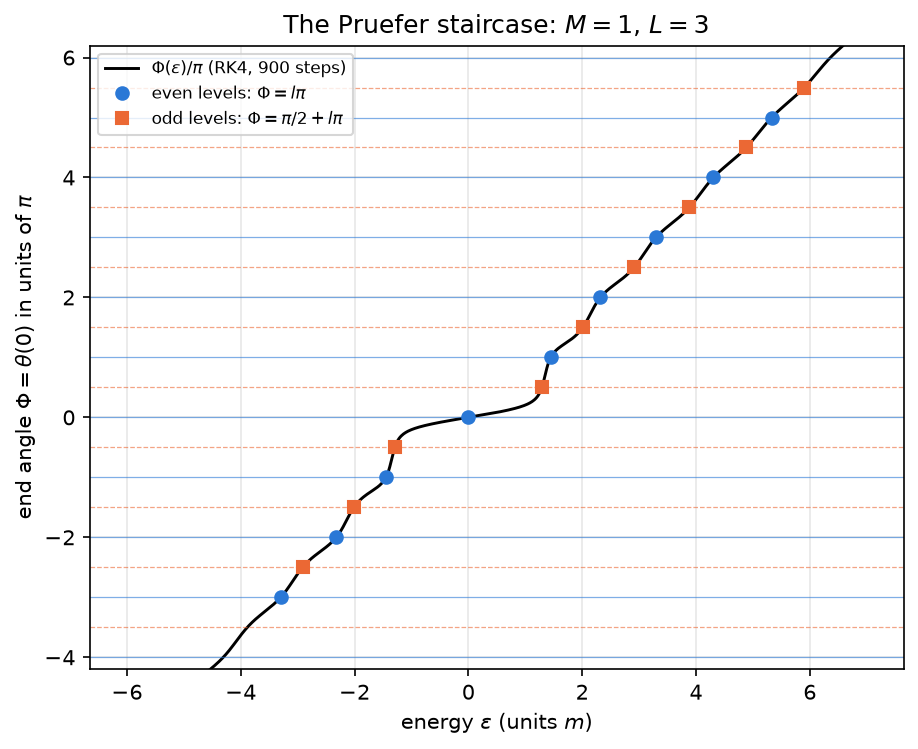

Figure 02d.1 saved as Revision/textbook/figures/02d_1_pruefer_staircase.png


In [4]:
eps_grid = np.linspace(-6.0, 7.0, 651)
shots = [shoot(e, M1, L3, 900) for e in eps_grid]  # (Phi, slope, largest turn)
Phi_grid = np.array([s[0] for s in shots])
slope_grid = np.array([s[1] for s in shots])  # dPhi/deps by the formula
check(np.all(np.diff(Phi_grid) > 0), "Phi(eps) increases on the whole grid")


def target(parity, label):
    """The target value of Phi for a level of the given parity and label."""
    return label * math.pi if parity == "even" else math.pi / 2 + label * math.pi


canonical = [r for r in ROWS if float(r["m"]) == 1.0 and float(r["L"]) == 3.0]
fig, ax = plt.subplots(figsize=(7.0, 5.4))
ax.plot(eps_grid, Phi_grid / math.pi, color=BLACK, lw=1.4,
        label="$\\Phi(\\varepsilon)/\\pi$ (RK4, 900 steps)")
for label in range(-4, 7):
    ax.axhline(label, color=BLUE, lw=0.6, alpha=0.6)
    ax.axhline(label + 0.5, color=ORANGE, lw=0.6, ls="--", alpha=0.6)
for r in canonical:
    is_even = r["parity"] == "even"
    ax.plot(float(r["eps_numeric"]), target(r["parity"], int(r["label"])) / math.pi,
            "o" if is_even else "s", color=BLUE if is_even else ORANGE, ms=6)
ax.plot([], [], "o", color=BLUE, label="even levels: $\\Phi = l\\pi$")
ax.plot([], [], "s", color=ORANGE, label="odd levels: $\\Phi = \\pi/2 + l\\pi$")
ax.set_ylim(-4.2, 6.2)
ax.set_xlabel("energy $\\varepsilon$ (units $m$)")
ax.set_ylabel("end angle $\\Phi = \\theta(0)$ in units of $\\pi$")
ax.set_title("The Pruefer staircase: $M = 1$, $L = 3$")
ax.legend(loc="upper left", fontsize=8)
save_figure(fig, "pruefer_staircase",
            "The end value of the Pruefer angle, $\\Phi(\\varepsilon) = "
            "\\theta(0)$ in units of $\\pi$ (vertical axis), against the energy "
            "$\\varepsilon$ in units of the mass $m$ from $-6$ to $7$ (horizontal "
            "axis), for $M = 1$, $L = 3$ and 900 RK4 steps. Blue lines: the even "
            "targets $l\\pi$; dashed orange lines: the odd targets "
            "$\\pi/2 + l\\pi$. Dots and squares: the 18 levels of the Revision "
            "record for this case. $\\Phi$ increases steadily, so it crosses every "
            "target exactly once: each level has its own label $l$, and even and "
            "odd levels alternate. The zero mode sits at $\\varepsilon = 0$, "
            "$\\Phi = 0$.")

## 8. The slope of the staircase

Section 4 proved $d\Phi/d\varepsilon = \int_{-L}^{0} r^2\,dy / r(0)^2$, which
is never negative. The next cell tests this formula in two ways. First, it
compares the formula (computed by `shoot` with the trapezoid rule) with the
*central difference* $(\Phi(\varepsilon + \delta) - \Phi(\varepsilon -
\delta))/(2\delta)$, $\delta = 10^{-4}$, at seven energies, and with the
value $(1 - e^{-2ML})/(2M)$ at $\varepsilon = 0$, where the shot is exactly
$a = e^{M(y + L)}$, $b = 0$ and the integral can be done by hand. Second, it
draws the formula over the whole grid together with the central differences of
the grid of section 7 (spacing 0.02). The slope is about $L = 3$ far from the
mass. Near $\varepsilon = 0$ it is about $1/(2M) = 0.5$: there the shot grows
like $e^{M(y + L)}$ and is largest at the brane, so $r(0)^2$ is large. Near
$|\varepsilon| = 1.34$ it is much larger, about 12.5: there the shot ends with a
small $r(0)$ compared with its size inside the interval, so a small change of
energy turns the end angle a lot, and the staircase climbs steeply.

eps = -4.00: formula   3.85717, central difference   3.85717
eps = -1.34: formula  12.49831, central difference  12.49830
eps = -0.50: formula   0.57078, central difference   0.57078
eps = +0.00: formula   0.49876, central difference   0.49876
eps = +0.70: formula   0.67374, central difference   0.67374
eps = +1.30: formula   9.67899, central difference   9.67899
eps = +3.00: formula   4.20995, central difference   4.20995
RESULT largest relative difference formula - central difference = 3.7e-06
PASS dPhi/deps = (integral of r^2)/r(0)^2 > 0 (agrees with central differences)
RESULT slope at eps = 0: formula, exact (1 - e^(-2ML))/(2M) = 0.498762, 0.498761
PASS at eps = 0 the slope is (1 - e^(-2ML))/(2M), about 1/(2M)


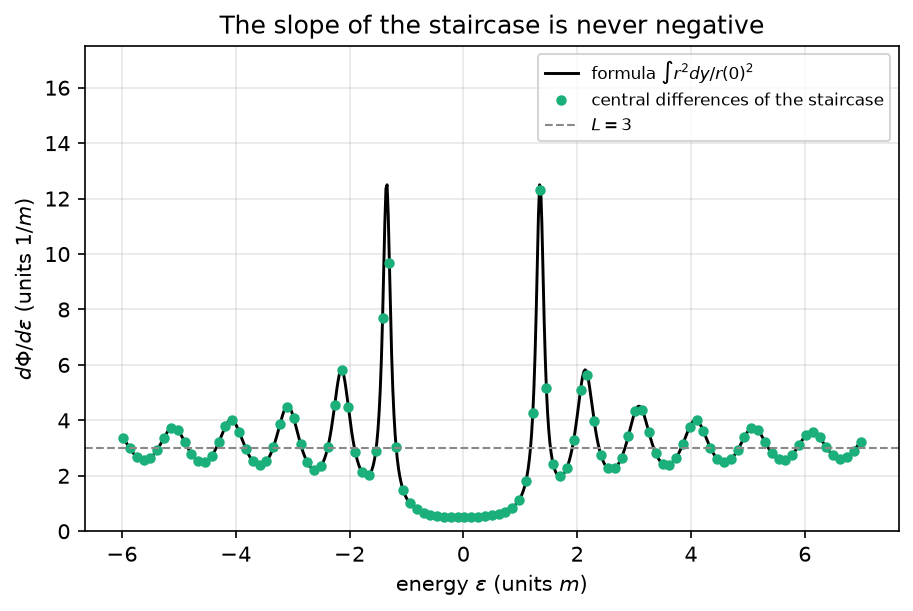

Figure 02d.2 saved as Revision/textbook/figures/02d_2_staircase_slope.png


In [5]:
DELTA = 1e-4  # the half-width of the central difference
tested = [-4.0, -1.34, -0.5, 0.0, 0.7, 1.3, 3.0]  # seven energies
relative = []
for e in tested:
    formula = shoot(e, M1, L3, 900)[1]  # element 1 of the result: the slope
    central = (shoot(e + DELTA, M1, L3, 900)[0]
               - shoot(e - DELTA, M1, L3, 900)[0]) / (2 * DELTA)
    relative.append(abs(central / formula - 1))
    say(f"eps = {e:+.2f}: formula {formula:9.5f}, central difference {central:9.5f}")
report("largest relative difference formula - central difference",
       f"{max(relative):.1e}")
check(max(relative) < 1e-4 and np.all(slope_grid > 0),
      "dPhi/deps = (integral of r^2)/r(0)^2 > 0 (agrees with central differences)")
# At eps = 0 the shot is exactly a = e^(M(y + L)), b = 0, so the integral can be
# done by hand: (e^(2ML) - 1)/(2M) divided by r(0)^2 = e^(2ML).
at_zero = (1 - math.exp(-2 * M1 * L3)) / (2 * M1)
report("slope at eps = 0: formula, exact (1 - e^(-2ML))/(2M)",
       f"{shoot(0.0, M1, L3, 900)[1]:.6f}, {at_zero:.6f}")
check(abs(shoot(0.0, M1, L3, 900)[1] - at_zero) < 1e-4,
      "at eps = 0 the slope is (1 - e^(-2ML))/(2M), about 1/(2M)")

grid_difference = (Phi_grid[2:] - Phi_grid[:-2]) / (eps_grid[2:] - eps_grid[:-2])
fig, ax = plt.subplots()
ax.plot(eps_grid, slope_grid, color=BLACK, lw=1.4,
        label="formula $\\int r^2 dy / r(0)^2$")
ax.plot(eps_grid[1:-1][::6], grid_difference[::6], "o", color=AQUA, ms=4,
        label="central differences of the staircase")
ax.axhline(L3, color=GREY, ls="--", lw=1.0, label="$L = 3$")
ax.set_ylim(0.0, 17.5)  # room for the legend above the two peaks
ax.set_xlabel("energy $\\varepsilon$ (units $m$)")
ax.set_ylabel("$d\\Phi/d\\varepsilon$ (units $1/m$)")
ax.set_title("The slope of the staircase is never negative")
ax.legend(loc="upper right", fontsize=8)
save_figure(fig, "staircase_slope",
            "The slope $d\\Phi/d\\varepsilon$ of the end angle (vertical axis, "
            "units $1/m$) against the energy $\\varepsilon$ in units of $m$ "
            "(horizontal axis), for $M = 1$, $L = 3$, 900 RK4 steps. Black line: "
            "the formula $\\int r^2 dy / r(0)^2$ proved with the product rule; "
            "aqua dots: central differences of the staircase of the previous "
            "figure. The slope is positive everywhere, which is why each level "
            "is crossed once. It is about $L = 3$ (dashed) far from the mass, "
            "about $1/(2M) = 0.5$ near $\\varepsilon = 0$, where the shot grows "
            "towards the brane, and large near $|\\varepsilon| = 1.34$, where the "
            "shot ends with a small $r(0)$ and the staircase climbs steeply.")

## 9. The angle along the interval

For five of the levels the next cell keeps the whole path and draws
$\theta(y)/\pi$ from the tip $y = -3$ to the brane $y = 0$. Each curve starts
at $0$ and ends exactly on its target; the number of half-turns it makes is the
label. The zero mode stays at $\theta = 0$ all the way ($b = 0$ everywhere).

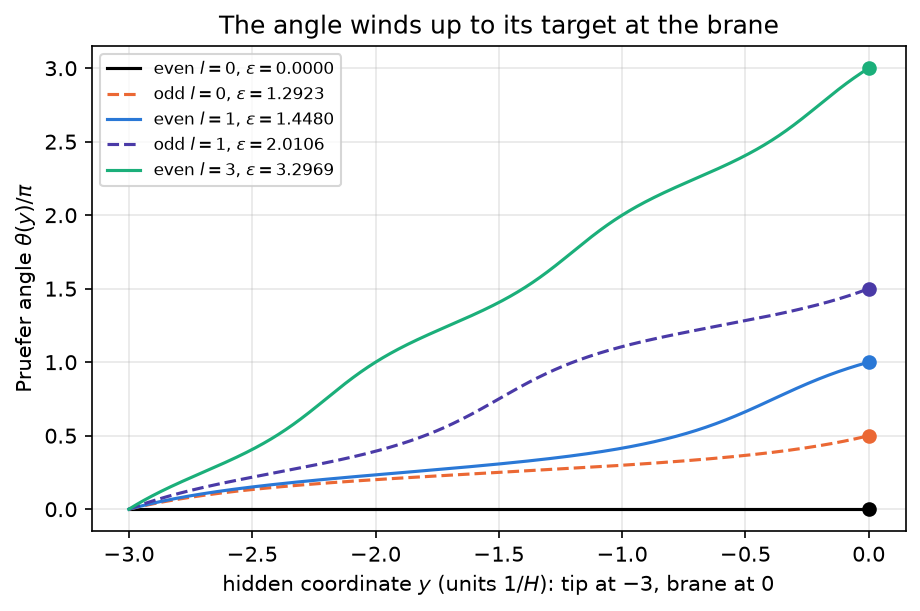

Figure 02d.3 saved as Revision/textbook/figures/02d_3_angle_along_y.png


In [6]:
chosen = [("even", 0), ("odd", 0), ("even", 1), ("odd", 1), ("even", 3)]
level_of = {(r["parity"], int(r["label"])): float(r["eps_numeric"]) for r in canonical}
fig, ax = plt.subplots()
for (parity, label), color in zip(chosen, [BLACK, ORANGE, BLUE, VIOLET, AQUA]):
    eps = level_of[(parity, label)]
    y_path, a_path, b_path, theta_path = shoot(eps, M1, L3, 900, keep=True)[3]
    ax.plot(y_path, theta_path / math.pi, color=color, lw=1.5,
            ls="-" if parity == "even" else "--",
            label=f"{parity} $l = {label}$, $\\varepsilon = {eps:.4f}$")
    ax.plot([0.0], [target(parity, label) / math.pi], "o", color=color, ms=6)
ax.set_xlabel("hidden coordinate $y$ (units $1/H$): tip at $-3$, brane at $0$")
ax.set_ylabel("Pruefer angle $\\theta(y)/\\pi$")
ax.set_title("The angle winds up to its target at the brane")
ax.legend(loc="upper left", fontsize=8)
save_figure(fig, "angle_along_y",
            "The Pruefer angle $\\theta(y)$ in units of $\\pi$ (vertical axis) "
            "along the hidden coordinate $y$ from the tip $y = -3$ to the brane "
            "$y = 0$ (horizontal axis, units $1/H$) for five levels of the case "
            "$M = 1$, $L = 3$: the zero mode (black, stays at 0), the odd label 0 "
            "(1.2923, ends at $\\pi/2$), the even label 1 (1.4480, ends at $\\pi$), "
            "the odd label 1 (2.0106, ends at $3\\pi/2$) and the even label 3 "
            "(3.2969, ends at $3\\pi$). Solid lines are even, dashed lines odd "
            "orbitals; every curve starts at 0 and ends on its target (dots).")

## 10. The exact levels, computed again

The odd levels need the roots $p$ of $\tan(pL) = -p/M$, which we write as
$M\sin(pL) + p\cos(pL) = 0$ (no infinities). The $n$-th root ($n = 0, 1, 2,
\dots$) lies between $(n + \frac{1}{2})\pi/L$ and $(n + 1)\pi/L$, where the
left side changes sign. The cell solves them with mpmath at 30 digits, forms
all 54 exact levels of the table (labels $-3$ to $5$ of both parities, for
$(M, L) = (1, 3), (1, 2), (2, 3)$; the odd label $l \ge 0$ uses the root
$p_l$ and $l \le -1$ the root $p_{-l-1}$ with the minus sign) and compares them
with the record's column `eps_analytic`. The figure shows the graphical
solution for $M = 1$, $L = 3$.

RESULT largest |exact level (here) - eps_analytic (record)| = 1.8e-15
PASS all 54 exact levels equal the column eps_analytic
     reproduces Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, column
    eps_analytic


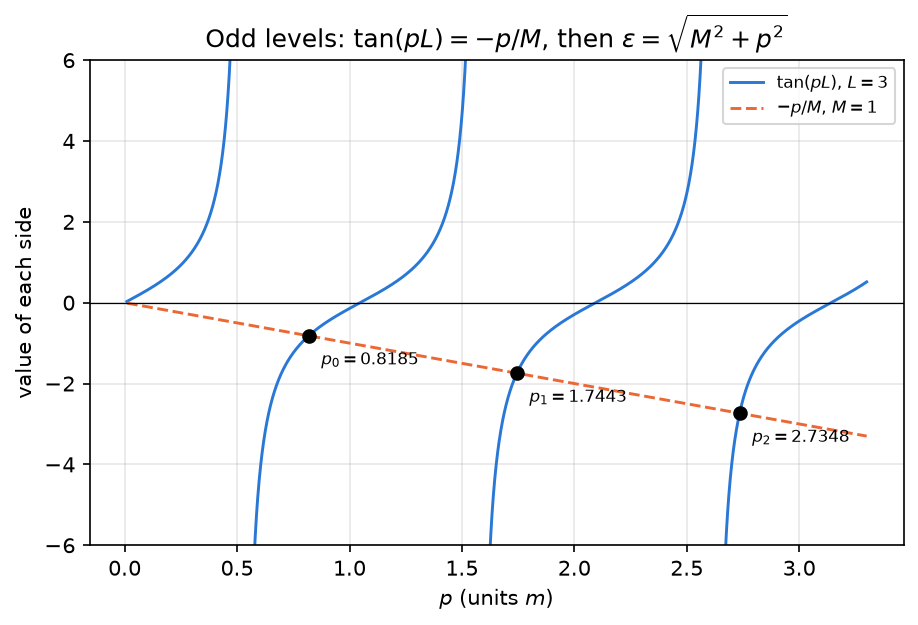

Figure 02d.4 saved as Revision/textbook/figures/02d_4_odd_level_equation.png


In [7]:
mpmath.mp.dps = 30


def odd_root(M, L, n):
    """The n-th positive root p of M sin(pL) + p cos(pL) = 0 (30 digits)."""
    g = lambda p: M * mpmath.sin(p * L) + p * mpmath.cos(p * L)  # noqa: E731
    return mpmath.findroot(g, ((n + 0.5) * mpmath.pi / L, (n + 1) * mpmath.pi / L),
                           solver="anderson")


def exact_level(M, L, parity, label):
    """The exact level of the given parity and label."""
    if parity == "even":
        if label == 0:
            return 0.0  # the zero mode
        return math.copysign(float(mpmath.sqrt(M ** 2 + (label * mpmath.pi / L) ** 2)),
                             label)
    n = label if label >= 0 else -label - 1
    value = float(mpmath.sqrt(M ** 2 + odd_root(M, L, n) ** 2))
    return value if label >= 0 else -value


analytic_ours = [exact_level(float(r["m"]), float(r["L"]), r["parity"],
                             int(r["label"])) for r in ROWS]
analytic_record = [float(r["eps_analytic"]) for r in ROWS]
worst_analytic = max(abs(a - b) for a, b in zip(analytic_ours, analytic_record))
report("largest |exact level (here) - eps_analytic (record)|", f"{worst_analytic:.1e}")
check(worst_analytic < 1e-14, "all 54 exact levels equal the column eps_analytic",
      record=f"{TABLE}, column eps_analytic")

p_axis = np.linspace(0.01, 3.3, 3000)
tangent = np.tan(p_axis * L3)
tangent[np.abs(tangent) > 8] = np.nan  # do not draw the jumps at the poles
fig, ax = plt.subplots()
ax.plot(p_axis, tangent, color=BLUE, lw=1.4, label="$\\tan(pL)$, $L = 3$")
ax.plot(p_axis, -p_axis / M1, color=ORANGE, lw=1.4, ls="--", label="$-p/M$, $M = 1$")
for n in range(3):
    p_n = float(odd_root(M1, L3, n))
    ax.plot([p_n], [-p_n], "o", color=BLACK, ms=6)
    ax.annotate(f"$p_{n} = {p_n:.4f}$", (p_n, -p_n), textcoords="offset points",
                xytext=(6, -14), fontsize=8)
ax.axhline(0.0, color=BLACK, lw=0.6)
ax.set_ylim(-6.0, 6.0)
ax.set_xlabel("$p$ (units $m$)")
ax.set_ylabel("value of each side")
ax.set_title("Odd levels: $\\tan(pL) = -p/M$, then $\\varepsilon = \\sqrt{M^2 + p^2}$")
ax.legend(loc="upper right", fontsize=8)
save_figure(fig, "odd_level_equation",
            "The equation of the odd levels for $M = 1$ and $L = 3$: the branches "
            "of $\\tan(pL)$ (solid blue) and the line $-p/M$ (dashed orange) "
            "against $p$ in units of $m$ (horizontal axis; the vertical axis is "
            "the value of each side, a pure number). Each crossing, one on every "
            "branch between $(n + 1/2)\\pi/L$ and $(n + 1)\\pi/L$, is a root "
            "$p_n$ and gives the two odd levels $\\pm\\sqrt{M^2 + p_n^2}$; the "
            "first three give 1.2923, 2.0106 and 2.9119.")

## 11. Newton's method with a safety net: the program's root finder

To find a level we must solve $F(\varepsilon) = \Phi(\varepsilon) - t = 0$ for
its target $t$. **Newton's method** replaces $F$ by its tangent line at the
current guess $\varepsilon_c$, $F(\varepsilon) \approx F(\varepsilon_c) +
F'(\varepsilon_c)(\varepsilon - \varepsilon_c)$, and takes the zero of that line
as the next guess:

$$\varepsilon_{\rm new} = \varepsilon_c - \frac{F(\varepsilon_c)}
{F'(\varepsilon_c)}, \qquad F'(\varepsilon) = \frac{d\Phi}{d\varepsilon} =
\frac{1}{r(0)^2}\int_{-L}^{0} r^2\,dy .$$

Close to the root the number of correct digits roughly doubles at every step.
Far from it the tangent can point anywhere, so the Rust program (function
`find_level` in Revision/kohn_sham/solver/src/shoot.rs) adds a safety net:

1. Shoot at the starting guess $\varepsilon = 0$; if $F(0) = 0$ exactly (the zero
   mode), stop.
2. Make a bracket: walk upwards (if $F < 0$) or downwards (if $F > 0$) with a
   first step of 1.2 times Newton's estimate (at least $10^{-4}$, at most 2),
   doubling the step until $F$ changes sign.
3. Newton steps inside the bracket; whenever Newton's point falls outside the
   bracket, or the mismatch $|F|$ has not at least halved since the last step,
   bisect instead. After each shot the bracket shrinks to the side that keeps
   the sign change.
4. Stop when the bracket is narrower than the tolerance $10^{-13}$, or when a
   Newton step is smaller than it.

The next cell writes this down in Python, step for step as in the Rust code,
and compares it with plain bisection (bracket $-12$ to $12$, halved until it is
narrower than $10^{-13}$) on the even level with label 3 of the case $M = 1$,
$L = 3$: the figure shows the error of every energy that is shot.

RESULT even label 3 by Newton = 3.296908309775607 (9 shots)
RESULT even label 3 by bisection = 3.296908309775617 (48 shots)
Newton shot 1: eps = 0.000000000000000, error 3.3e+00
Newton shot 2: eps = 2.000000000000000, error 1.3e+00
Newton shot 3: eps = 6.000000000000000, error 2.7e+00
Newton shot 4: eps = 3.147568065578289, error 1.5e-01
Newton shot 5: eps = 3.279643841475118, error 1.7e-02
Newton shot 6: eps = 3.296597009921515, error 3.1e-04
Newton shot 7: eps = 3.296908208194133, error 1.0e-07
Newton shot 8: eps = 3.296908309775594, error 1.3e-14
Newton shot 9: eps = 3.296908309775607, error 0.0e+00


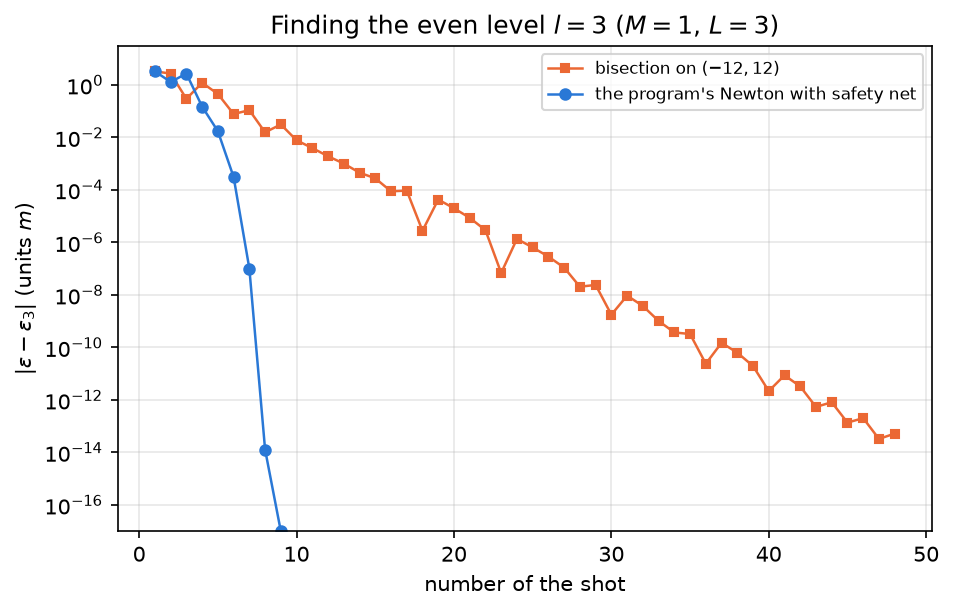

Figure 02d.5 saved as Revision/textbook/figures/02d_5_newton_vs_bisection.png
PASS Newton (fewer than 15 shots) gives the record's level; bisection agrees
     reproduces Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, column
    eps_numeric


In [8]:
def find_level(M, L, G, goal, tolerance=ROOT_TOLERANCE, log=None):
    """The energy with Phi(eps) = goal, found as the Rust program finds it.  If log
    is a list, every energy that is shot is appended to it."""
    def mismatch(eps):
        Phi, slope, largest = shoot(eps, M, L, G)
        if largest >= 2.0:  # the program refuses such a shot
            raise ValueError(f"one step turns the angle by {largest:.2f}")
        if log is not None:
            log.append(eps)
        return Phi - goal, slope  # F(eps) and F'(eps)

    e_c = 0.0  # step 1: the starting guess
    F_c, dF_c = mismatch(e_c)
    if F_c == 0.0:
        return e_c
    if F_c < 0.0:  # step 2, upwards: the level lies above
        low = e_c
        step = min(max(1.2 * (-F_c / dF_c), 1e-4), 2.0)
        while True:
            e = low + step
            F, dF = mismatch(e)
            if F >= 0.0:  # the sign changed: the bracket is (low, e)
                high = e
                if abs(F) < abs(F_c):  # keep the better of the two guesses
                    e_c, F_c, dF_c = e, F, dF
                break
            low, e_c, F_c, dF_c = e, e, F, dF  # still below: move on
            step *= 2.0
    else:  # step 2, downwards: the level lies below
        high = e_c
        step = min(max(1.2 * (F_c / dF_c), 1e-4), 2.0)
        while True:
            e = high - step
            F, dF = mismatch(e)
            if F <= 0.0:  # the sign changed: the bracket is (e, high)
                low = e
                if abs(F) < abs(F_c):
                    e_c, F_c, dF_c = e, F, dF
                break
            high, e_c, F_c, dF_c = e, e, F, dF
            step *= 2.0
    if F_c == 0.0:
        return e_c
    previous = math.inf  # |F| at the previous step
    for _ in range(300):  # step 3
        if high - low <= tolerance:  # step 4: the bracket is narrow enough
            break
        e_new = e_c - F_c / dF_c  # Newton's point
        bisect = not (low < e_new < high) or abs(F_c) > 0.5 * previous
        if bisect:
            e_new = 0.5 * (low + high)  # the safety net
        previous = abs(F_c)
        F, dF = mismatch(e_new)
        moved = abs(e_new - e_c)
        e_c, F_c, dF_c = e_new, F, dF
        if F == 0.0:
            break
        if F < 0.0:  # keep the half of the bracket with the sign change
            low = e_new
        else:
            high = e_new
        if moved <= tolerance and not bisect:  # step 4: a tiny Newton step
            break
    return e_c


def find_level_by_bisection(M, L, G, goal, tolerance=ROOT_TOLERANCE, log=None):
    """The same level by plain bisection on the bracket (-12, 12)."""
    low, high = -12.0, 12.0
    while high - low > tolerance:
        middle = 0.5 * (low + high)
        if log is not None:
            log.append(middle)
        if shoot(middle, M, L, G)[0] < goal:
            low = middle
        else:
            high = middle
    return 0.5 * (low + high)


newton_log, bisection_log = [], []
by_newton = find_level(M1, L3, 900, target("even", 3), log=newton_log)
by_bisection = find_level_by_bisection(M1, L3, 900, target("even", 3),
                                       log=bisection_log)
report("even label 3 by Newton", f"{by_newton:.15f} ({len(newton_log)} shots)")
report("even label 3 by bisection",
       f"{by_bisection:.15f} ({len(bisection_log)} shots)")
for k, e in enumerate(newton_log, 1):
    say(f"Newton shot {k}: eps = {e:.15f}, error {abs(e - by_newton):.1e}")
fig, ax = plt.subplots()
ax.semilogy(range(1, len(bisection_log) + 1),
            np.maximum(np.abs(np.array(bisection_log) - by_newton), 1e-17), "s-",
            color=ORANGE, ms=4, lw=1.2, label="bisection on $(-12, 12)$")
ax.semilogy(range(1, len(newton_log) + 1),
            np.maximum(np.abs(np.array(newton_log) - by_newton), 1e-17), "o-",
            color=BLUE, ms=5, lw=1.2, label="the program's Newton with safety net")
ax.set_ylim(1e-17, 30.0)
ax.set_xlabel("number of the shot")
ax.set_ylabel("$|\\varepsilon - \\varepsilon_3|$ (units $m$)")
ax.set_title("Finding the even level $l = 3$ ($M = 1$, $L = 3$)")
ax.legend(loc="upper right", fontsize=8)
save_figure(fig, "newton_vs_bisection",
            "The distance $|\\varepsilon - \\varepsilon_3|$ (units of $m$, "
            "logarithmic vertical axis) of every energy that is shot from the "
            "even level with label 3, $\\varepsilon_3 = 3.2969$, of the case "
            "$M = 1$, $L = 3$, against the number of the shot (horizontal axis). "
            "Squares: bisection, which halves the bracket $(-12, 12)$ at every "
            "shot and needs 48 shots to reach the tolerance $10^{-13}$. Circles: "
            "the Rust program's root finder, which first walks up from 0 to make "
            "a bracket and then takes Newton steps; once close, each step about "
            "doubles the number of correct digits, and it stops after 9 shots. "
            "Distances of exactly zero are drawn at $10^{-17}$.")
check(abs(by_newton - level_of[("even", 3)]) < 1e-12
      and abs(by_bisection - by_newton) < 1e-13
      and len(newton_log) < 15 < 45 < len(bisection_log),
      "Newton (fewer than 15 shots) gives the record's level; bisection agrees",
      record=f"{TABLE}, column eps_numeric")

## 12. All 54 levels, against the Rust program

Now the whole table. For each row the cell takes the target of its parity and
label and finds the energy with `find_level`, with the program's number of RK4
steps $G = 900 L/3$ (900 for $L = 3$, 600 for $L = 2$: the same step
$h = 1/300$). It writes every level as the program writes numbers (16
significant digits, exponents like `e0`) and compares the text with the
record's column `eps_numeric`. On the computer that made the record all 54 are
identical; on another computer the function atan2 of the system's mathematics
library may round differently in the last binary place, and a last digit may
differ, so the check asks for agreement within $10^{-12}$ (ten times the root
tolerance). The record keeps 16 digits, so even an identical level differs from
the number read back from the record by up to about $10^{-15}$.

Then it recomputes the two numbers that the program's check
`free_k0_analytic_spectra` quotes: the largest $|\varepsilon_{\rm numeric} -
\varepsilon_{\rm exact}|$ for $|\varepsilon| < 4m$ and for $|\varepsilon| \ge
4m$. (The check's text calls the second band "$4m \le |\varepsilon| < 7m$", but
the Rust code, file Revision/kohn_sham/solver/src/spectrum.rs, puts every level
with $|\varepsilon| \ge 4m$ into it, and the table goes up to $8.75m$; the cell
prints both numbers.)

In [9]:
def rust_text(x):
    """x written as the Rust program writes numbers: 16 digits, exponent like e0."""
    mantissa, exponent = f"{x:.15e}".split("e")  # Python writes e+00, Rust e0
    return f"{mantissa}e{int(exponent)}"


CASES = [(1.0, 3.0), (1.0, 2.0), (2.0, 3.0)]  # the three cases (M, L) of the table
numeric_ours, shots_per_level = [], []
for r in ROWS:
    M, L = float(r["m"]), float(r["L"])
    G = round(G_CANONICAL * L / 3.0)  # 900 steps for L = 3, 600 for L = 2
    log = []
    numeric_ours.append(find_level(M, L, G, target(r["parity"], int(r["label"])),
                                   log=log))
    shots_per_level.append(len(log))
numeric_record = [float(r["eps_numeric"]) for r in ROWS]
identical = sum(rust_text(x) == r["eps_numeric"] for x, r in zip(numeric_ours, ROWS))
worst_numeric = max(abs(a - b) for a, b in zip(numeric_ours, numeric_record))
report("levels whose 16 digits equal the column eps_numeric", f"{identical} of 54")
report("largest |level (here) - eps_numeric (Rust program)|", f"{worst_numeric:.1e}")
report("shots per level (fewest, most, all 54 together)",
       f"{min(shots_per_level)}, {max(shots_per_level)}, {sum(shots_per_level)}")
check(worst_numeric < 1e-12 and max(shots_per_level) <= 20,
      "all 54 shooting levels equal the column eps_numeric (at most 20 shots each)",
      record=f"{TABLE}, column eps_numeric")
zero_rows = [i for i, r in enumerate(ROWS) if r["parity"] == "even"
             and int(r["label"]) == 0]
check(all(numeric_ours[i] == 0.0 == numeric_record[i] for i in zero_rows),
      "the zero mode has the energy exactly 0 in all three cases",
      record=f"{SOLVER_REPORT}, check free_zero_mode_exact")

differences_ours = [n - a for n, a in zip(numeric_ours, analytic_ours)]
pairs = list(zip(differences_ours, analytic_ours))
low_band = max(abs(d) for d, a in pairs if abs(a) < 4)  # all levels below 4 m
high_band = max(abs(d) for d, a in pairs if abs(a) >= 4)  # all levels from 4 m on
below_7 = max(abs(d) for d, a in pairs if 4 <= abs(a) < 7)
top = max(abs(a) for _, a in pairs)  # the highest level of the table
solver_report = json.loads(repository_file(SOLVER_REPORT).read_text(encoding="utf-8"))
detail = [c["detail"] for c in solver_report["checks"]
          if c["name"] == "free_k0_analytic_spectra"][0]
quoted = float(re.findall(r"max \|difference\| ([0-9.]+e-[0-9]+) for \|eps\| < 4 m",
                          detail)[0])
quoted_high = float(re.findall(r"([0-9.]+e-[0-9]+) for 4 m <= \|eps\| < 7 m",
                               detail)[0])
report("largest |numeric - exact| for |eps| < 4 m (here, record)",
       f"{low_band:.2e}, {quoted:.2e}")
report("largest |numeric - exact| for |eps| >= 4 m (here, record)",
       f"{high_band:.2e}, {quoted_high:.2e}")
say(f"Note: the record's check text names its second band 4 m <= |eps| < 7 m, but "
    f"the solver puts every level with |eps| >= 4 m into it, and the table's "
    f"levels reach {top:.4f} m; the quoted number belongs to that level. For "
    f"4 m <= |eps| < 7 m alone the largest difference is {below_7:.2e}.")
check(abs(low_band / quoted - 1) < 0.005 and abs(high_band / quoted_high - 1) < 0.005,
      "the two largest differences quoted by the solver check are reproduced",
      record=f"{SOLVER_REPORT}, check free_k0_analytic_spectra")

RESULT levels whose 16 digits equal the column eps_numeric = 54 of 54
RESULT largest |level (here) - eps_numeric (Rust program)| = 8.9e-16
RESULT shots per level (fewest, most, all 54 together) = 1, 15, 510
PASS all 54 shooting levels equal the column eps_numeric (at most 20 shots each)
     reproduces Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, column
    eps_numeric
PASS the zero mode has the energy exactly 0 in all three cases
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_zero_mode_exact
RESULT largest |numeric - exact| for |eps| < 4 m (here, record) = 7.23e-10, 7.23e-10
RESULT largest |numeric - exact| for |eps| >= 4 m (here, record) = 5.05e-08, 5.05e-08
Note: the record's check text names its second band 4 m <= |eps| < 7 m, but the solver
    puts every level with |eps| >= 4 m into it, and the table's levels reach 8.7539 m;
    the quoted number belongs to that level. For 4 m <= |eps| < 7 m alone the largest
    difference is 9.95e-09

## 13. The orbitals

The next cell builds the normalised orbitals of four levels of the canonical
case as the Rust program builds them (function `profile` in shoot.rs): the
values at the $G + 1$ step ends (*nodes*) come from the RK4 shot; the values in
the middle of every step from *cubic interpolation*: the cubic polynomial that
has the values $f_0, f_1$ and the slopes $f_0', f_1'$ at the two ends of a step
of length $h$ takes in the middle the value $(f_0 + f_1)/2 + h(f_0' - f_1')/8$
(check it on $f = y^2$ and $f = y^3$ on the step from 0 to $h$); the slopes
come from the equations themselves. On this fine grid of $2G + 1$ points the
norm $\int_{-L}^{0} (a^2 + b^2)\, dy$ is computed with Simpson's rule (weights
$1, 4, 2, 4, \dots, 4, 1$ times one third of the spacing $h/2$), and the orbital
is divided by its square root. The cell draws $a(y)$ and $b(y)$, checks the
brane condition of each ($b(0) = 0$ even, $a(0) = 0$ odd), and measures how far
the computed zero mode is from its exact form
$a = \sqrt{2M/(1 - e^{-2ML})}\, e^{M y}$, $b = 0$ (the normalised $e^{My}$): the
program's check `free_zero_mode_exact` quotes this distance.

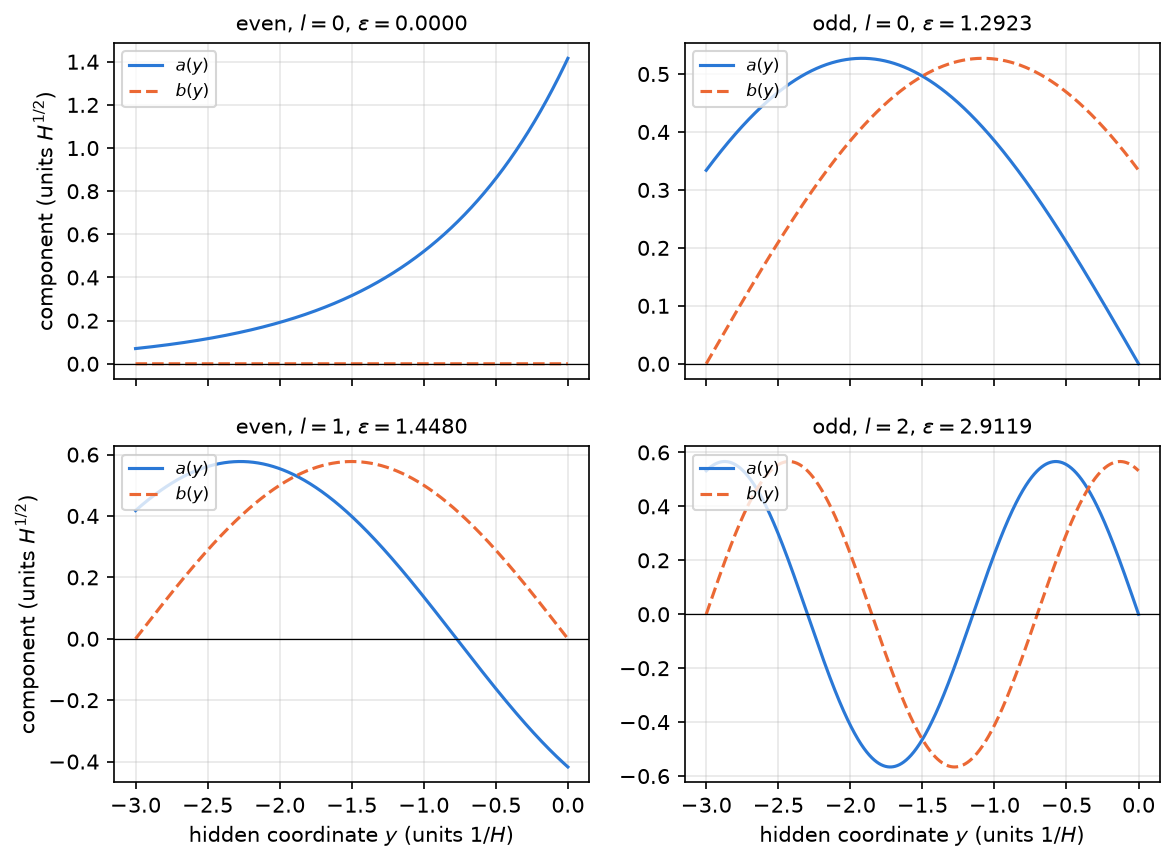

Figure 02d.6 saved as Revision/textbook/figures/02d_6_orbitals.png
RESULT largest brane residual |b(0)| or |a(0)| = 8.6e-16
RESULT zero mode: largest distance from the exact normalised form (here, record) =
    1.35e-12, 1.35e-12
PASS every orbital meets its brane condition within 1e-10
PASS the zero mode: b = 0 exactly, distance 1.35e-12 from sqrt(2M/(1 - e^(-2ML))) e^(My)
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    free_zero_mode_exact


In [10]:
def orbital(eps, M, L, G):
    """The normalised orbital on the fine grid of 2G + 1 points, made as the Rust
    program makes it.  Returns the arrays y, a, b."""
    h = L / G
    nf = 2 * G + 1  # nodes and step midpoints
    y = -L * ((nf - 1 - np.arange(nf)) / (nf - 1))  # the fine grid, as in the program
    _, a_nodes, b_nodes, _ = shoot(eps, M, L, G, keep=True)[3]
    da = M * a_nodes - eps * b_nodes  # the slopes a' at the nodes (the equations)
    db = eps * a_nodes - M * b_nodes  # the slopes b'
    a, b = np.zeros(nf), np.zeros(nf)
    a[0::2], b[0::2] = a_nodes, b_nodes  # the nodes take the even places
    a[1::2] = 0.5 * (a_nodes[:-1] + a_nodes[1:]) + h / 8.0 * (da[:-1] - da[1:])
    b[1::2] = 0.5 * (b_nodes[:-1] + b_nodes[1:]) + h / 8.0 * (db[:-1] - db[1:])
    half = 0.5 * h  # the spacing of the fine grid
    weights = np.full(nf, 2.0 * half / 3.0)  # Simpson: 2 at the even inner places
    weights[1::2] = 4.0 * half / 3.0  # 4 at the odd places (the midpoints)
    weights[0] = weights[-1] = half / 3.0  # 1 at the two ends
    scale = 1.0 / math.sqrt(np.sum(weights * (a * a + b * b)))
    return y, a * scale, b * scale


fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.4), sharex=True)
residuals = []
for ax, (parity, label) in zip(axes.flat, [("even", 0), ("odd", 0), ("even", 1),
                                          ("odd", 2)]):
    eps = level_of[(parity, label)]
    y_fine, a_fine, b_fine = orbital(eps, M1, L3, 900)
    end = b_fine[-1] if parity == "even" else a_fine[-1]  # must vanish at y = 0
    residuals.append(abs(end))
    ax.plot(y_fine, a_fine, color=BLUE, lw=1.5, label="$a(y)$")
    ax.plot(y_fine, b_fine, color=ORANGE, lw=1.5, ls="--", label="$b(y)$")
    ax.axhline(0.0, color=BLACK, lw=0.6)
    ax.set_title(f"{parity}, $l = {label}$, $\\varepsilon = {eps:.4f}$", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")
    if parity == "even" and label == 0:  # the zero mode against its exact form
        exact_a = math.sqrt(2 * M1 / (1 - math.exp(-2 * M1 * L3))) * np.exp(M1 * y_fine)
        zero_mode_distance = np.max(np.abs(a_fine - exact_a))
        zero_mode_b = np.max(np.abs(b_fine))
for ax in axes[1]:
    ax.set_xlabel("hidden coordinate $y$ (units $1/H$)")
for ax in axes[:, 0]:
    ax.set_ylabel("component (units $H^{1/2}$)")
save_figure(fig, "orbitals",
            "The normalised orbitals of four levels of the case $M = 1$, $L = 3$: "
            "the components $a(y)$ (solid blue) and $b(y)$ (dashed orange) against "
            "the hidden coordinate $y$ from the tip $-3$ to the brane $0$ "
            "(horizontal axes, units $1/H$; vertical axes in units of $H^{1/2}$, so "
            "that $\\int (a^2 + b^2) dy = 1$). Top left: the zero mode "
            "$a \\propto e^{y}$, $b = 0$, concentrated at the brane. Top right: odd "
            "label 0. Bottom: even label 1 and odd label 2. Every orbital has "
            "$b = 0$ at the tip; at the brane the even ones have $b = 0$ and the "
            "odd ones $a = 0$.")
report("largest brane residual |b(0)| or |a(0)|", f"{max(residuals):.1e}")
zero_detail = [c["detail"] for c in solver_report["checks"]
               if c["name"] == "free_zero_mode_exact"][0]
zero_quoted = float(re.findall(r"e\^\(My\) to ([0-9.]+e-[0-9]+)", zero_detail)[0])
report("zero mode: largest distance from the exact normalised form (here, record)",
       f"{zero_mode_distance:.2e}, {zero_quoted:.2e}")
check(max(residuals) < 1e-10, "every orbital meets its brane condition within 1e-10")
check(zero_mode_b == 0.0 and abs(zero_mode_distance / zero_quoted - 1) < 0.01,
      "the zero mode: b = 0 exactly, distance 1.35e-12 from sqrt(2M/(1 - e^(-2ML))) "
      "e^(My)", record=f"{SOLVER_REPORT}, check free_zero_mode_exact")

## 14. How the error depends on the step

The levels inherit the RK4 error. The next cell repeats the search for three
levels of the canonical case with $G = 25, 50, 100, 200, 400, 800$ steps and
draws the error against the step $h = L/G$ (log-log; the slope is the order).

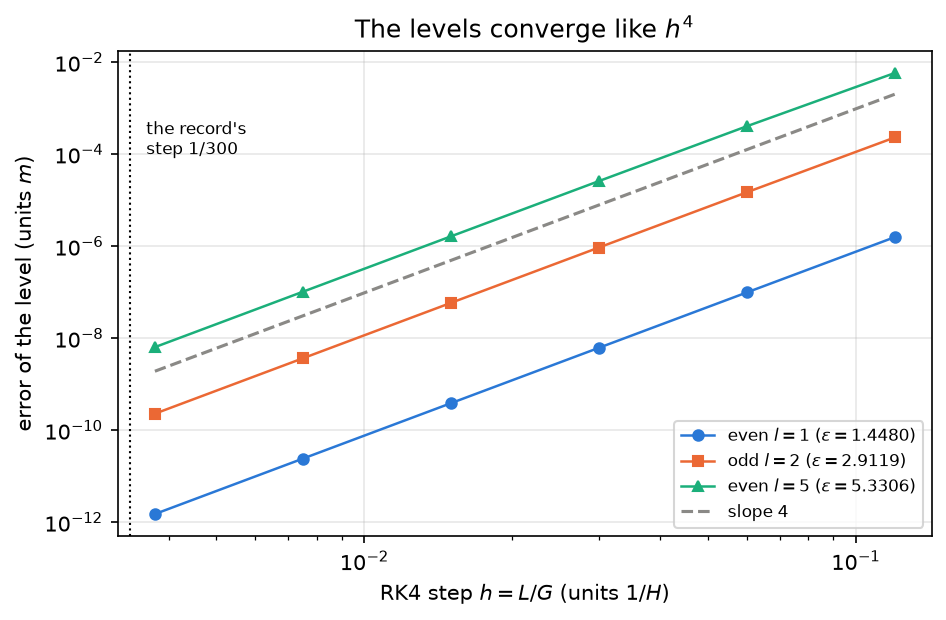

Figure 02d.7 saved as Revision/textbook/figures/02d_7_level_convergence.png
RESULT measured orders = 4.00, 3.99, 3.97
PASS the level errors fall like h^4


In [11]:
G_LIST = [25, 50, 100, 200, 400, 800]
tracked = [("even", 1), ("odd", 2), ("even", 5)]
fig, ax = plt.subplots()
orders = []
for (parity, label), color, marker in zip(tracked, [BLUE, ORANGE, AQUA],
                                          ["o", "s", "^"]):
    exact = exact_level(M1, L3, parity, label)
    errors = np.array([abs(find_level(M1, L3, G, target(parity, label)) - exact)
                       for G in G_LIST])
    h_list = L3 / np.array(G_LIST, dtype=float)
    fit = errors > 1e-11  # leave out points limited by the root tolerance
    orders.append(np.polyfit(np.log10(h_list[fit]), np.log10(errors[fit]), 1)[0])
    ax.loglog(h_list, errors, marker=marker, color=color, ms=5, lw=1.2,
              label=f"{parity} $l = {label}$ ($\\varepsilon = {exact:.4f}$)")
h_guide = L3 / np.array(G_LIST, dtype=float)
ax.loglog(h_guide, 2e-3 * (h_guide / h_guide[0]) ** 4, "--", color=GREY,
          label="slope 4")
ax.axvline(L3 / 900, color=BLACK, ls=":", lw=1.0)
ax.text(L3 / 900 * 1.08, 1e-4, "the record's\nstep 1/300", fontsize=8)
ax.set_xlabel("RK4 step $h = L/G$ (units $1/H$)")
ax.set_ylabel("error of the level (units $m$)")
ax.set_title("The levels converge like $h^4$")
ax.legend(loc="lower right", fontsize=8)
save_figure(fig, "level_convergence",
            "The error of three levels of the case $M = 1$, $L = 3$ found by "
            "shooting, against the RK4 step $h = L/G$ for $G = 25$ to 800 steps "
            "(logarithmic axes; the error in units of $m$, the step in units of "
            "$1/H$): even label 1 (circles), odd label 2 (squares), even label 5 "
            "(triangles). The points follow lines of slope 4 (dashed guide): the "
            "levels have the order of RK4, and higher levels have larger errors. "
            "The dotted line marks the record's step $1/300$.")
report("measured orders", ", ".join(f"{q:.2f}" for q in orders))
check(all(3.8 < q < 4.2 for q in orders), "the level errors fall like h^4")

**Why the error grows with the level.** Far above the mass, $\theta' \approx
\varepsilon$: the point $(a, b)$ turns at the rate $\varepsilon$. One RK4 step
multiplies a turning point by $R(i\omega)$ with $\omega = \varepsilon h$ (the
amplification factor of the test equation $y' = i\varepsilon y$), whose angle
is a little SMALLER than the exact $\omega$. The next cell lets sympy expand the
angle of $R(i\omega)$: it is $\omega - \omega^5/120 + \dots$ After $G = L/h$
steps the end angle lags by about $L\, \varepsilon^5 h^4/120$; since $\Phi$
grows by about $L$ per unit of energy, the computed level comes out too high by

$$\delta\varepsilon \approx \frac{\varepsilon^5 h^4}{120}, \qquad
\frac{\delta\varepsilon}{\varepsilon} \approx \frac{(h\varepsilon)^4}{120} .$$

The figure draws the relative error $\delta\varepsilon/\varepsilon$ of all 51
nonzero levels of the record (the record's column `difference`) against
$h|\varepsilon|$ with $h = 1/300$, with our own differences on top, and this
prediction as a line. Close to the mass the point does not turn uniformly
($\theta' = \varepsilon - M \sin 2\theta$), and the error is smaller than the
prediction; far above it the points approach the line.

angle of R(i omega) - omega = -omega**5/120 + ...
PASS one RK4 step turns by omega - omega^5/120: the phase lags


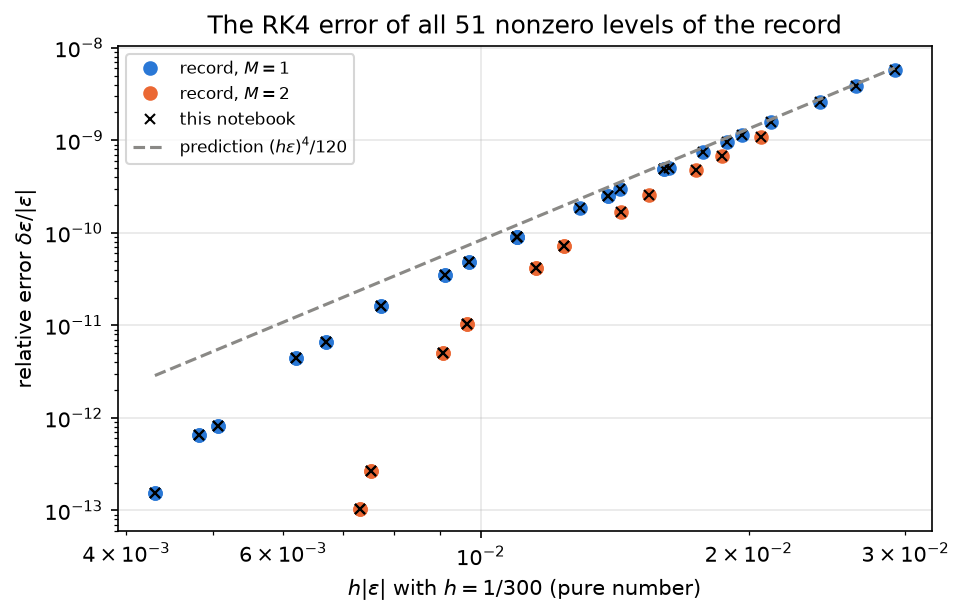

Figure 02d.8 saved as Revision/textbook/figures/02d_8_record_differences.png
RESULT error / prediction for the levels above 7 m = 0.934, 0.953, 0.955
PASS every level error lies below the prediction, within 10 % above 7 m
RESULT largest |difference (here) - difference (record)| = 1.8e-15
PASS our differences equal the record's column difference within 1e-12
     reproduces Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, column
    difference


In [12]:
w = sp.symbols("omega", positive=True)  # the angle turned in one step, eps h
R_rk4 = 1 + sp.I * w - w ** 2 / 2 - sp.I * w ** 3 / 6 + w ** 4 / 24  # R(i omega)
turned = sp.atan(sp.im(R_rk4) / sp.re(R_rk4))  # the angle of R(i omega)
lag = sp.series(turned - w, w, 0, 7).removeO()
say(f"angle of R(i omega) - omega = {lag} + ...")
check(sp.simplify(lag + w ** 5 / 120) == 0,
      "one RK4 step turns by omega - omega^5/120: the phase lags")

nonzero = [i for i, a in enumerate(analytic_record) if a != 0.0]
eps_abs = np.array([abs(analytic_record[i]) for i in nonzero])
x_values = eps_abs / 300.0  # h |eps| with h = 1/300
record_diff = np.array([abs(float(ROWS[i]["difference"])) for i in nonzero])
our_diff = np.array([abs(differences_ours[i]) for i in nonzero])
masses = np.array([float(ROWS[i]["m"]) for i in nonzero])
fig, ax = plt.subplots()
for mass, color in ((1.0, BLUE), (2.0, ORANGE)):
    pick = masses == mass
    ax.loglog(x_values[pick], record_diff[pick] / eps_abs[pick], "o", color=color,
              ms=6, label=f"record, $M = {mass:.0f}$")
ax.loglog(x_values, our_diff / eps_abs, "x", color=BLACK, ms=5,
          label="this notebook")
x_guide = np.linspace(x_values.min(), x_values.max(), 50)
ax.loglog(x_guide, x_guide ** 4 / 120, "--", color=GREY,
          label="prediction $(h\\varepsilon)^4/120$")
ax.set_xlabel("$h |\\varepsilon|$ with $h = 1/300$ (pure number)")
ax.set_ylabel("relative error $\\delta\\varepsilon / |\\varepsilon|$")
ax.set_title("The RK4 error of all 51 nonzero levels of the record")
ax.legend(loc="upper left", fontsize=8)
save_figure(fig, "record_differences",
            "The relative error $\\delta\\varepsilon/|\\varepsilon|$ of the "
            "shooting levels for all 51 nonzero levels of the Revision record of "
            "the free spectrum (vertical axis, a pure number), against "
            "$h|\\varepsilon|$ with the record's step $h = 1/300$ (horizontal "
            "axis, a pure number), on logarithmic axes. Dots: the record's column "
            "difference divided by the level, for $M = 1$ (blue; $L = 3$ and "
            "$L = 2$) and $M = 2$ (orange); crosses: this notebook's shooting, "
            "which falls on the record's points. Dashed: the prediction "
            "$(h\\varepsilon)^4/120$ from the phase lag of one RK4 step; the "
            "levels far above the mass approach it, those near the mass lie "
            "below it.")
ratio = (record_diff / eps_abs) / (x_values ** 4 / 120)
report("error / prediction for the levels above 7 m",
       ", ".join(f"{q:.3f}" for q in ratio[eps_abs > 7]))
check(np.all(ratio < 1) and np.all(ratio[eps_abs > 7] > 0.9),
      "every level error lies below the prediction, within 10 % above 7 m")
report("largest |difference (here) - difference (record)|",
       f"{np.max(np.abs(record_diff - our_diff)):.1e}")
check(np.max(np.abs(record_diff - our_diff)) < 1e-12,
      "our differences equal the record's column difference within 1e-12",
      record=f"{TABLE}, column difference")

## 15. The last check

The last cell checks that all 8 figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [13]:
names = ["pruefer_staircase", "staircase_slope", "angle_along_y",
         "odd_level_equation", "newton_vs_bisection", "orbitals",
         "level_convergence", "record_differences"]
present = [output_file(f"{FIGURE_FOLDER}/02d_{k}_{name}.png").is_file()
           for k, name in enumerate(names, 1)]
check(all(present), f"all {len(names)} figure files of notebook 02d exist")
all_checks_passed()

PASS all 8 figure files of notebook 02d exist
ALL 17 CHECKS PASSED (notebook 02d)


## 16. What this notebook showed

- The free Kohn-Sham block of the book, $a' = M a - \varepsilon b$,
  $b' = \varepsilon a - M b$ with $b(-L) = 0$ and $b(0) = 0$ or $a(0) = 0$, has
  the exact levels $0$ (the zero mode $a \propto e^{My}$, $b = 0$),
  $\pm\sqrt{M^2 + (n\pi/L)^2}$ (even) and $\pm\sqrt{M^2 + p^2}$ with
  $\tan(pL) = -p/M$ (odd).
- The Pruefer angle obeys $\theta' = \varepsilon - M\sin 2\theta$, and the
  product rule gives $d\Phi/d\varepsilon = \int r^2\,dy / r(0)^2 > 0$: the end
  value increases with $\varepsilon$, so each level is the unique crossing of a
  target $l\pi$ or $\pi/2 + l\pi$; no level can be missed and each has a label.
- The Rust program finds a level with Newton's method (slope from the same
  formula) and a bisection safety net: 9 shots for the even level $l = 3$,
  where plain bisection needs 48.
- Re-written line by line in Python, the program's shooting (900 RK4 steps for
  $L = 3$) and root finder reproduce all 54 levels of the record
  Revision/kohn_sham/results/spectrum/free-k0-analytic.csv (on the computer
  that made the record, identical in all 16 printed digits), the exact column,
  the zero mode exactly, the distance $1.35 \times 10^{-12}$ of the computed zero
  mode from its exact form, and the numbers $7.23 \times 10^{-10}$ (levels below
  $4m$) and $5.05 \times 10^{-8}$ (all levels from $4m$ up to $8.75m$; the
  check's text says "below $7m$") quoted by the program's check
  free_k0_analytic_spectra.
- The level errors fall like $h^4$; for levels far above the mass the relative
  error is close to $(h\varepsilon)^4/120$, the phase lag of RK4. The canonical
  step $h = 1/300$ gives errors below $10^{-9}$ for $|\varepsilon| < 4m$.
- What this notebook does not show: the physics of these equations (where they
  come from, the meaning of the levels, the interacting case); the brane
  conditions rest on the ASSUMED mirror symmetry and the tip condition is a
  choice of the model, as the record states.